In [942]:
import ezdxf
import geopandas as gpd
from shapely.geometry import LineString, Point, MultiPoint
import matplotlib.pyplot as plt
import pandas as pd
import networkx as nx
from shapely.ops import substring, snap
from collections import defaultdict

from pathlib import Path

PROJECT_ROOT = Path.cwd().parent 

In [943]:
doc = ezdxf.readfile(PROJECT_ROOT / "SNEE_2026/data/netz_plan.dxf")
msp = doc.modelspace()

lines = []
for entity in msp.query("LWPOLYLINE"):
    type(entity)
    pts = list(entity.get_points())
    coords = [(p[0], p[1]) for p in pts]
    line_geometry = LineString(coords)
    length = line_geometry.length
    lines.append({
        "geometry": LineString(coords),
        "length_m": length
     
    })

lines_gdf = gpd.GeoDataFrame(lines, crs="EPSG:25832")  # CRS anpassen

<Axes: >

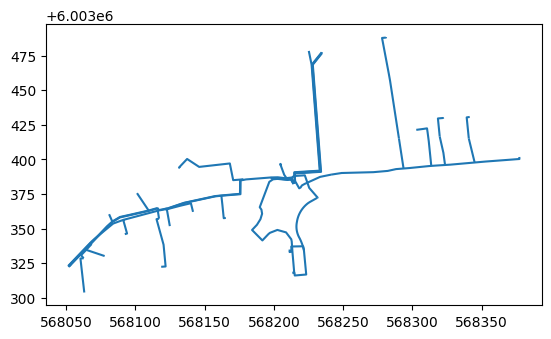

In [944]:
lines_gdf.plot()

In [945]:
lines_gdf["start"] = lines_gdf["geometry"].apply(lambda geom: Point(geom.coords[0]))
lines_gdf["end"] = lines_gdf["geometry"].apply(lambda geom: Point(geom.coords[-1]))
lines_gdf

,geometry,length_m,start,end
0,"LINESTRING (568319.778 6003416.482, 568322.434...",20.940786,POINT (568319.778 6003416.482),POINT (568323.621 6003395.917)
1,"LINESTRING (568215.521 6003382.951, 568215.422...",31.198707,POINT (568215.521 6003382.951),POINT (568241.323 6003388.954)
2,"LINESTRING (568212.708 6003334.175, 568212.532...",14.334626,POINT (568212.708 6003334.175),POINT (568221.568 6003334.599)
3,"LINESTRING (568197.75 6003386.727, 568199.347 ...",18.861694,POINT (568197.75 6003386.727),POINT (568214.3 6003382.264)
4,"LINESTRING (568214.649 6003382.46, 568212.213 ...",8.116835,POINT (568214.649 6003382.46),POINT (568209.083 6003386.439)
5,"LINESTRING (568213.449 6003318.207, 568214.668...",120.900017,POINT (568213.449 6003318.207),POINT (568214.126 6003382.166)
6,"LINESTRING (568116.846 6003364.447, 568115.27 ...",62.804876,POINT (568116.846 6003364.447),POINT (568064 6003335.029)
7,"LINESTRING (568231.324 6003372.195, 568228.415...",74.485711,POINT (568231.324 6003372.195),POINT (568213.48 6003317.808)
8,"LINESTRING (568293.621 6003393.373, 568293.541...",21.956226,POINT (568293.621 6003393.373),POINT (568290.321 6003415.079)
9,"LINESTRING (568052.987 6003322.686, 568052.349...",153.517207,POINT (568052.987 6003322.686),POINT (568177.967 6003385.548)


In [946]:
# Als GeoSeries damit sindex funktioniert
points_gs = gpd.GeoSeries(pd.concat([lines_gdf["start"], lines_gdf["end"]])).reset_index(drop=True)

bus_coords = {}
clustered_points = []
bus_index = 0
for index, point in points_gs.items():
    if index not in clustered_points:
        # gibt Array von Indices zurück
        nearest_indices = set(points_gs.sindex.query(
            point.buffer(2.5),
            predicate="intersects"
        ))
        nearest_indices = [int(x) for x in nearest_indices]
        
        clustered_points.extend(nearest_indices)
     
        # Koordinaten der gefundenen Punkte sammeln
        nearest_points_coords = [Point(points_gs[i].coords) for i in nearest_indices]
        
        centroid = MultiPoint(nearest_points_coords).centroid
        # bus_index als Key, centroid + original indices als Value
        bus_coords[bus_index]= {"geometry": centroid, "nearest_points": nearest_points_coords}
        
        print(f"Bus {bus_index}: {len(nearest_points_coords)} Punkte → Centroid {centroid}")
        bus_index += 1
        
    else:
        continue

Bus 0: 2 Punkte → Centroid POINT (568319.778 6003416.482)
Bus 1: 10 Punkte → Centroid POINT (568214.928 6003382.6166)
Bus 2: 5 Punkte → Centroid POINT (568211.8929999999 6003333.9212)
Bus 3: 1 Punkte → Centroid POINT (568197.75 6003386.727)
Bus 4: 2 Punkte → Centroid POINT (568213.4645 6003318.0075)
Bus 5: 4 Punkte → Centroid POINT (568117.207 6003363.45425)
Bus 6: 2 Punkte → Centroid POINT (568231.324 6003372.195)
Bus 7: 1 Punkte → Centroid POINT (568293.621 6003393.373)
Bus 8: 4 Punkte → Centroid POINT (568052.899 6003322.592999999)
Bus 9: 1 Punkte → Centroid POINT (568341.43 6003430.613999999)
Bus 10: 1 Punkte → Centroid POINT (568280.9420000002 6003488.267)
Bus 11: 1 Punkte → Centroid POINT (568132.06 6003393.532999999)
Bus 12: 1 Punkte → Centroid POINT (568165.255 6003357.682)
Bus 13: 1 Punkte → Centroid POINT (568141.584 6003362.07)
Bus 14: 1 Punkte → Centroid POINT (568124.828 6003351.766)
Bus 15: 1 Punkte → Centroid POINT (568118.5940000002 6003322.377)
Bus 16: 1 Punkte → Centr

# Matche die Busse zu den Lines

In [947]:
start_buses = []
end_buses = []

for row in lines_gdf.itertuples():
    start_point = row.start
    end_point = row.end
    start_bus_index = None
    end_bus_index = None
    
    for bus_index, props in bus_coords.items():
        if start_point in props["nearest_points"]:
            start_bus_index = bus_index
            print("Matched start!")

        if end_point in props["nearest_points"]:
            end_bus_index = bus_index
            print("Matched end!")
            
    
    start_buses.append(start_bus_index)
    end_buses.append(end_bus_index)

lines_gdf["start_bus"] = start_buses
lines_gdf["end_bus"] = end_buses
    
        
bus_gdf = gpd.GeoDataFrame.from_dict(bus_coords, orient="index").drop("nearest_points", axis=1)
# print(bus_gdf)
print(lines_gdf)
    

Matched start!
Matched end!
Matched start!
Matched end!
Matched start!
Matched end!
Matched end!
Matched start!
Matched start!
Matched end!
Matched end!
Matched start!
Matched start!
Matched end!
Matched end!
Matched start!
Matched start!
Matched end!
Matched start!
Matched end!
Matched start!
Matched end!
Matched start!
Matched end!
Matched start!
Matched end!
Matched start!
Matched end!
Matched start!
Matched end!
Matched start!
Matched end!
Matched start!
Matched end!
Matched start!
Matched end!
Matched start!
Matched end!
Matched start!
Matched end!
Matched start!
Matched end!
Matched end!
Matched start!
Matched end!
Matched start!
Matched end!
Matched start!
Matched end!
Matched start!
Matched start!
Matched end!
Matched start!
Matched end!
Matched end!
Matched start!
Matched end!
Matched start!
Matched end!
Matched start!
Matched end!
Matched start!
Matched start!
Matched end!
Matched start!
Matched end!
Matched end!
Matched start!
Matched start!
Matched end!
Matched end!
Matched

In [948]:
bus_gdf

,geometry
0,POINT (568319.778 6003416.482)
1,POINT (568214.928 6003382.617)
2,POINT (568211.893 6003333.921)
3,POINT (568197.75 6003386.727)
4,POINT (568213.464 6003318.008)
5,POINT (568117.207 6003363.454)
6,POINT (568231.324 6003372.195)
7,POINT (568293.621 6003393.373)
8,POINT (568052.899 6003322.593)
9,POINT (568341.43 6003430.614)


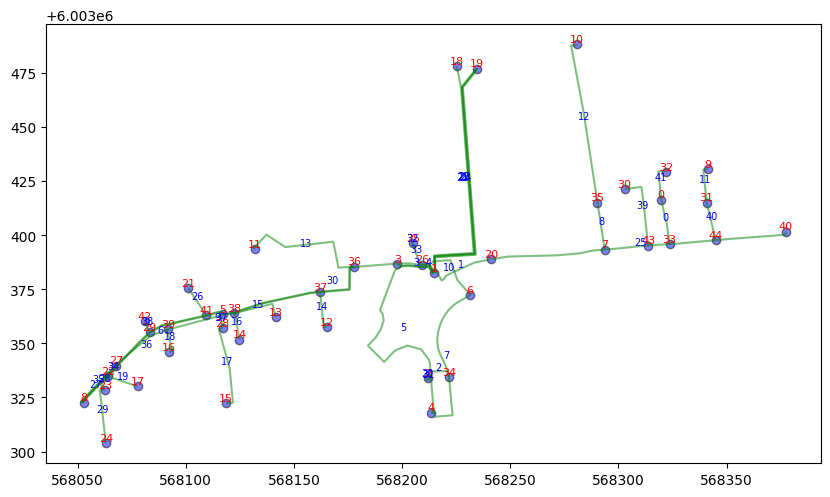

In [949]:
fig, ax = plt.subplots(figsize=(10, 10))

lines_gdf.plot(ax=ax, color='green', alpha=0.5, edgecolor='k', label='Lines')
bus_gdf.plot(ax=ax, color='blue', alpha=0.5, edgecolor='k', label='Busses')

# Bus-Index
for idx, row in bus_gdf.iterrows():
    ax.annotate(
        text=str(idx),
        xy=(row.geometry.x, row.geometry.y),
        fontsize=8,
        color='red',
        ha='center',
        va='bottom'
    )

# Line-Index – Centroid des LineStrings nutzen
for idx, row in lines_gdf.iterrows():
    centroid = row.geometry.centroid
    ax.annotate(
        text=str(idx),
        xy=(centroid.x, centroid.y),
        fontsize=7,
        color='blue',
        ha='center',
        va='bottom'
    )


# Überprüfen, ob es lines gibt auf denen oder in deren Nähe ein Punkt liegt der nicht damit verbunden ist -> wenn sie nicht verbunden sind über Anfangs oder Endpunkte, muss die Line aufgesplittet werden

In [950]:
lines_gdf

,geometry,length_m,start,end,start_bus,end_bus
0,"LINESTRING (568319.778 6003416.482, 568322.434...",20.940786,POINT (568319.778 6003416.482),POINT (568323.621 6003395.917),0,33
1,"LINESTRING (568215.521 6003382.951, 568215.422...",31.198707,POINT (568215.521 6003382.951),POINT (568241.323 6003388.954),1,20
2,"LINESTRING (568212.708 6003334.175, 568212.532...",14.334626,POINT (568212.708 6003334.175),POINT (568221.568 6003334.599),2,34
3,"LINESTRING (568197.75 6003386.727, 568199.347 ...",18.861694,POINT (568197.75 6003386.727),POINT (568214.3 6003382.264),3,1
4,"LINESTRING (568214.649 6003382.46, 568212.213 ...",8.116835,POINT (568214.649 6003382.46),POINT (568209.083 6003386.439),1,26
5,"LINESTRING (568213.449 6003318.207, 568214.668...",120.900017,POINT (568213.449 6003318.207),POINT (568214.126 6003382.166),4,1
6,"LINESTRING (568116.846 6003364.447, 568115.27 ...",62.804876,POINT (568116.846 6003364.447),POINT (568064 6003335.029),5,22
7,"LINESTRING (568231.324 6003372.195, 568228.415...",74.485711,POINT (568231.324 6003372.195),POINT (568213.48 6003317.808),6,4
8,"LINESTRING (568293.621 6003393.373, 568293.541...",21.956226,POINT (568293.621 6003393.373),POINT (568290.321 6003415.079),7,35
9,"LINESTRING (568052.987 6003322.686, 568052.349...",153.517207,POINT (568052.987 6003322.686),POINT (568177.967 6003385.548),8,36


In [951]:
# --- Schritt 1: Für jede Line alle darauf liegenden Buses sammeln ---

tolerance = 1# 1 m in EPSG:25832

def get_endpoints(line):
    coords = list(line.coords)
    return Point(coords[0]), Point(coords[-1])

tolerance = 0.01  # 1 cm in EPSG:25832
bus_sindex = bus_gdf.sindex
buses_on_line = defaultdict(list)

for line_idx, line_row in lines_gdf.iterrows():
    line = line_row.geometry
    start, end = get_endpoints(line)
    start_bus = line_row["start"]
    end_bus = line_row["end"]
    
    # Kandidaten via sindex vorfiltern – nur Buses in Toleranz zur Line
    candidate_idxs = bus_sindex.query(line, predicate="dwithin", distance=tolerance)
    candidates = bus_gdf.iloc[candidate_idxs]
    
    for bus_idx, bus_row in candidates.iterrows():
        bus_point = bus_row.geometry
        
        # Kein Endpunkt der Line
        if bus_point == start_bus  or bus_point == end_bus:
            print(f"Punkt ist Endpunkt bus {bus_idx}")
        else:
            buses_on_line[line_idx].append(bus_point)
            print("Punkt ist nicht festgelegter Split!")

print(f"{len(buses_on_line)} Lines haben unverbundene Busse darauf:")
for line_idx, points in buses_on_line.items():
    print(f"  Line {line_idx}: {len(points)} Bus/-se")

# --- Schritt 2: Jede betroffene Line an ALLEN Punkten auf einmal splitten ---

def split_line_at_points(line, points, tolerance=0.01):
    """
    Splittet eine Line an mehreren Punkten.
    n Punkte → n+1 Segmente
    """
    # Distanz jedes Punktes entlang der Line berechnen und sortieren
    distances = sorted([
        line.project(snap(p, line, tolerance)) 
        for p in points
    ])
    
    print(f"  Projektierte Distanzen: {[round(d, 3) for d in distances]}")
    
    segments = []
    prev_dist = 0.0
    
    for dist in distances:
        # Null-Segmente vermeiden (Punkt liegt auf Endpunkt)
        if dist - prev_dist > tolerance:
            seg = substring(line, prev_dist, dist)
            segments.append(seg)
        prev_dist = dist
    
    # Letztes Segment bis zum Linienende
    if line.length - prev_dist > tolerance:
        seg = substring(line, prev_dist, line.length)
        segments.append(seg)
    
    return segments

new_lines_rows = []

for line_idx, bus_points in buses_on_line.items():
    original_line_row = lines_gdf.loc[line_idx]
    segments = split_line_at_points(original_line_row.geometry, bus_points)
    
    # Mapping: Geometrie → Bus-Label-Index (für alle beteiligten Punkte)
    # Start/End-Buses der originalen Line
    start_bus_label = original_line_row["start_bus"]
    end_bus_label = original_line_row["end_bus"]
    
    # Split-Buses: bus_point → label_idx
    split_point_to_bus = {}
    for bus_point in bus_points:
        pos_idxs = bus_gdf.sindex.query(bus_point, predicate="dwithin", distance=tolerance)
        if len(pos_idxs) > 0:
            label_idx = bus_gdf.index[pos_idxs[0]]
            split_point_to_bus[label_idx] = bus_gdf.at[label_idx, "geometry"]
    
    # Alle beteiligten Punkte: original Start + Split-Buses + original End
    # In Reihenfolge entlang der Line sortiert (wie beim Split)
    all_bus_labels = [start_bus_label] + list(split_point_to_bus.keys()) + [end_bus_label]
    all_bus_labels_sorted = sorted(
        all_bus_labels,
        key=lambda lbl: original_line_row.geometry.project(bus_gdf.at[lbl, "geometry"])
    )
    
    print(f"Line {line_idx}: Bus-Reihenfolge: {all_bus_labels_sorted}")
    
    # Segmente mit bekannten Bus-Labels verknüpfen
    for i, seg in enumerate(segments):
        start_label = all_bus_labels_sorted[i]
        end_label = all_bus_labels_sorted[i + 1]
        
        new_row = original_line_row.copy()
        new_row["geometry"] = seg
        new_row["length"] = seg.length
        new_row["start"] = bus_gdf.at[start_label, "geometry"]
        new_row["end"] = bus_gdf.at[end_label, "geometry"]
        new_row["start_bus"] = start_label
        new_row["end_bus"] = end_label
        new_lines_rows.append(new_row)
        
# --- Schritt 3: Originale Lines löschen und neue einfügen ---

lines_to_drop = list(buses_on_line.keys())

lines_gdf_fixed = pd.concat(
    [
        lines_gdf.drop(index=lines_to_drop),
        gpd.GeoDataFrame(new_lines_rows, crs=lines_gdf.crs)
    ],
    ignore_index=True
)

print(f"\nVorher: {len(lines_gdf)} Lines")
print(f"Nachher: {len(lines_gdf_fixed)} Lines (+{len(lines_gdf_fixed) - len(lines_gdf)} neue Segmente)")

Punkt ist Endpunkt bus 33
Punkt ist Endpunkt bus 0
Punkt ist Endpunkt bus 20
Punkt ist Endpunkt bus 34
Punkt ist Endpunkt bus 3
Punkt ist Endpunkt bus 26
Punkt ist nicht festgelegter Split!
Punkt ist Endpunkt bus 6
Punkt ist Endpunkt bus 7
Punkt ist Endpunkt bus 35
Punkt ist nicht festgelegter Split!
Punkt ist Endpunkt bus 36
Punkt ist nicht festgelegter Split!
Punkt ist Endpunkt bus 6
Punkt ist Endpunkt bus 31
Punkt ist Endpunkt bus 9
Punkt ist Endpunkt bus 35
Punkt ist Endpunkt bus 10
Punkt ist Endpunkt bus 36
Punkt ist Endpunkt bus 11
Punkt ist Endpunkt bus 12
Punkt ist Endpunkt bus 37
Punkt ist Endpunkt bus 13
Punkt ist Endpunkt bus 14
Punkt ist Endpunkt bus 15
Punkt ist Endpunkt bus 28
Punkt ist Endpunkt bus 16
Punkt ist Endpunkt bus 39
Punkt ist Endpunkt bus 17
Punkt ist Endpunkt bus 18
Punkt ist nicht festgelegter Split!
Punkt ist Endpunkt bus 20
Punkt ist nicht festgelegter Split!
Punkt ist nicht festgelegter Split!
Punkt ist nicht festgelegter Split!
Punkt ist nicht festgelegt

# Überprüfen, dass das Netz gut verbunden ist

In [952]:
G = nx.Graph()

nodes_dict = bus_gdf.to_dict(orient="Index")
print(nodes_dict)
G.add_nodes_from(nodes_dict.keys())
nx.set_node_attributes(G, nodes_dict)

# Prüfen:
G.nodes[1]  # {'geometry': <POINT ...>}

for line in lines_gdf_fixed.itertuples():
    index = line.index
    start = line.start_bus
    end = line.end_bus
    
    G.add_edge(start, end, name=index)
    
# Ist der Graph vollständig verbunden?
print(nx.is_connected(G))  # True / False

# Anzahl der verbundenen Teilgraphen
print(nx.number_connected_components(G))  # z.B. 3

# Generator aller verbundenen Komponenten (als Sets von Node-IDs)
components = list(nx.connected_components(G))
print(components)
# [{1, 2, 5, 8}, {3, 7}, {4}]  → 3 isolierte Teilnetze

# Größte Komponente
largest = max(components, key=len)
print(largest)  # {1, 2, 5, 8}

isolated = list(nx.isolates(G))
print(isolated)  # [4, 9, ...]

{0: {'geometry': <POINT (568319.778 6003416.482)>}, 1: {'geometry': <POINT (568214.928 6003382.617)>}, 2: {'geometry': <POINT (568211.893 6003333.921)>}, 3: {'geometry': <POINT (568197.75 6003386.727)>}, 4: {'geometry': <POINT (568213.464 6003318.008)>}, 5: {'geometry': <POINT (568117.207 6003363.454)>}, 6: {'geometry': <POINT (568231.324 6003372.195)>}, 7: {'geometry': <POINT (568293.621 6003393.373)>}, 8: {'geometry': <POINT (568052.899 6003322.593)>}, 9: {'geometry': <POINT (568341.43 6003430.614)>}, 10: {'geometry': <POINT (568280.942 6003488.267)>}, 11: {'geometry': <POINT (568132.06 6003393.533)>}, 12: {'geometry': <POINT (568165.255 6003357.682)>}, 13: {'geometry': <POINT (568141.584 6003362.07)>}, 14: {'geometry': <POINT (568124.828 6003351.766)>}, 15: {'geometry': <POINT (568118.594 6003322.377)>}, 16: {'geometry': <POINT (568092.305 6003345.959)>}, 17: {'geometry': <POINT (568077.741 6003330.142)>}, 18: {'geometry': <POINT (568225.205 6003478.308)>}, 19: {'geometry': <POINT (